# Customer Segmentation and Purchase Behaviour
Business questions: which customers buy recently, repeatedly and at higher value; how do returns affect value; and what differentiated actions could be tested?

One transaction row is an invoice line, not an order. CustomerID is the customer key. RFM uses completed positive-price purchases; credit/return records are reported separately. Clusters describe historical behaviour and are not churn predictions. The uploaded file matches the familiar Online Retail schema; original download provenance was not supplied. Reference dataset documentation: https://archive.ics.uci.edu/dataset/352/online+retail . Verify provenance and reuse terms before redistribution.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score
BASE = Path.cwd()
OUT = BASE / 'outputs'; OUT.mkdir(exist_ok=True)
SEED = 42
plt.rcParams.update({'figure.dpi':120})
INPUT = BASE / 'data.csv'
raw = pd.read_csv(INPUT, encoding='latin1', dtype={'InvoiceNo':'string','StockCode':'string','CustomerID':'string'})
required = {'InvoiceNo','StockCode','Quantity','InvoiceDate','UnitPrice','CustomerID','Country'}
assert required.issubset(raw.columns)
print('Raw rows:',len(raw)); print(raw.isna().sum().to_string())

Raw rows: 541909
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0


## Cleaning with an auditable population
Remove exact duplicate rows as a documented assumption (the source lacks an invoice-line key, so duplicates could be legitimate). Keep unknown customers for scope reporting but exclude them from customer profiles. Do not require Description for RFM. Exclude explicitly listed service, fee, discount, manual adjustment and gift codes from merchandise analysis; this is a scope choice, not proof that all excluded codes are invalid. Preserve an exclusion audit. Missing/invalid transaction keys, dates or numeric values are quarantined.

Purchase = non-C invoice, Quantity > 0 and UnitPrice > 0. Credit/return = Quantity < 0 and UnitPrice > 0, regardless of prefix. Other combinations are exceptions, never purchases. Return values are observed credit-line magnitudes; credits cannot be matched to original orders and may refer to purchases outside this window.

In [2]:
audit = []
def audit_stage(stage,frame):
    audit.append({'Stage':stage,'Rows':len(frame),'KnownCustomers':frame.CustomerID.nunique()})
audit_stage('Raw',raw)
tx = raw.drop_duplicates().copy(); audit_stage('After exact deduplication',tx)
for col in ['InvoiceNo','StockCode','CustomerID']:
    tx[col] = tx[col].str.strip().replace('',pd.NA)
tx['CustomerID'] = tx.CustomerID.str.replace(r'\.0$','',regex=True)
tx['InvoiceDate'] = pd.to_datetime(tx.InvoiceDate,format='%m/%d/%Y %H:%M',errors='coerce')
for col in ['Quantity','UnitPrice']:
    tx[col] = pd.to_numeric(tx[col],errors='coerce')
valid = tx[['InvoiceNo','StockCode','InvoiceDate','Quantity','UnitPrice']].notna().all(axis=1)
valid &= np.isfinite(tx.Quantity) & np.isfinite(tx.UnitPrice)
tx.loc[~valid].to_csv(OUT/'invalid_rows.csv',index=False)
tx = tx.loc[valid].copy(); audit_stage('Valid transaction fields',tx)
reference_date = tx.InvoiceDate.max().normalize() + pd.Timedelta(days=1)
excluded_codes = {'POST','DOT','M','D','C2','S','BANK CHARGES','AMAZONFEE','CRUK','B'}
excluded = tx.StockCode.str.upper().isin(excluded_codes) | tx.StockCode.str.lower().str.startswith('gift_')
tx.loc[excluded].groupby('StockCode').size().rename('Rows').to_csv(OUT/'excluded_codes.csv')
tx = tx.loc[~excluded].copy(); audit_stage('Merchandise scope',tx)
tx = tx.loc[tx.CustomerID.notna()].copy(); audit_stage('Identified customers',tx)
is_credit = tx.InvoiceNo.str.upper().str.startswith('C')
tx['Type'] = np.select([(tx.Quantity>0)&(tx.UnitPrice>0)&~is_credit,
                       (tx.Quantity<0)&(tx.UnitPrice>0)],['Purchase','CreditReturn'],default='Exception')
tx['LineValue'] = tx.Quantity * tx.UnitPrice
classification = tx.groupby('Type').agg(Rows=('InvoiceNo','size'),Invoices=('InvoiceNo','nunique'),Customers=('CustomerID','nunique'),SignedValue=('LineValue','sum'))
classification.to_csv(OUT/'transaction_types.csv')
tx.loc[tx.Type.eq('Exception')].to_csv(OUT/'exception_rows.csv',index=False)
purchases = tx.loc[tx.Type.eq('Purchase')].copy()
returns = tx.loc[tx.Type.eq('CreditReturn')].copy()
assert len(purchases)>0
pd.DataFrame(audit).to_csv(OUT/'cleaning_audit.csv',index=False)
print(pd.DataFrame(audit).to_string(index=False)); print(classification.to_string())
print('Reference date:',reference_date.date())

                    Stage   Rows  KnownCustomers
                      Raw 541909            4372
After exact deduplication 536641            4372
 Valid transaction fields 536641            4372
        Merchandise scope 533701            4363
     Identified customers 399693            4363
                Rows  Invoices  Customers  SignedValue
Type                                                  
CreditReturn    8506      3383       1534  -471750.710
Exception         34        28         25        0.000
Purchase      391153     18402       4334  8737227.643
Reference date: 2011-12-10


## Customer metrics and reconciliation
Recency = calendar days from last valid purchase to the day after the dataset's last valid transaction. Frequency = distinct purchase invoices. GrossPurchaseValue = sum of positive merchandise purchase lines. ReturnValue = absolute credit-line value. NetSpend = gross purchases minus observed credits. These are merchandise transaction values, not profit or a reconciled accounting ledger.

Customer profiles include return-only customers; only customers with at least one purchase enter RFM clustering. ReturnInvoiceShare uses return invoices / (purchase invoices + return invoices), not the probability that a purchase was returned. Average purchase gaps use sorted distinct invoices; single-order customers have undefined gaps.

In [3]:
customers = pd.DataFrame(index=pd.Index(sorted(tx.CustomerID.unique()),name='CustomerID'))
purchase_metrics = purchases.groupby('CustomerID').agg(LastPurchase=('InvoiceDate','max'),Frequency=('InvoiceNo','nunique'),GrossPurchaseValue=('LineValue','sum'),UnitsPurchased=('Quantity','sum'),ProductDiversity=('StockCode','nunique'))
return_metrics = returns.groupby('CustomerID').agg(ReturnInvoices=('InvoiceNo','nunique'),ReturnValue=('LineValue',lambda s:-s.sum()))
customers = customers.join(purchase_metrics).join(return_metrics)
for col in ['Frequency','GrossPurchaseValue','UnitsPurchased','ProductDiversity','ReturnInvoices','ReturnValue']:
    customers[col] = customers[col].fillna(0)
customers['RecencyDays'] = (reference_date - customers.LastPurchase.dt.normalize()).dt.days
customers['NetSpend'] = customers.GrossPurchaseValue - customers.ReturnValue
customers['AverageOrderValue'] = customers.GrossPurchaseValue.div(customers.Frequency.replace(0,np.nan))
customers['ReturnInvoiceSharePct'] = customers.ReturnInvoices.div((customers.Frequency+customers.ReturnInvoices).replace(0,np.nan))*100
orders = purchases.groupby(['CustomerID','InvoiceNo'],as_index=False).agg(InvoiceDate=('InvoiceDate','min'),OrderValue=('LineValue','sum'))
orders = orders.sort_values(['CustomerID','InvoiceDate','InvoiceNo'])
orders['GapDays'] = orders.groupby('CustomerID').InvoiceDate.diff().dt.total_seconds()/86400
customers = customers.join(orders.groupby('CustomerID').GapDays.mean().rename('AverageGapDays'))
np.testing.assert_allclose(customers.GrossPurchaseValue.sum(),purchases.LineValue.sum())
np.testing.assert_allclose(customers.ReturnValue.sum(),-returns.LineValue.sum())
np.testing.assert_allclose(customers.NetSpend.sum(),purchases.LineValue.sum()+returns.LineValue.sum())
assert customers.Frequency.sum() == len(orders)
assert customers.index.is_unique
eligible = customers.loc[customers.Frequency>0].copy()
assert eligible.RecencyDays.notna().all() and (eligible.RecencyDays>=0).all()
customers.to_csv(OUT/'all_customer_metrics.csv')
orders.to_csv(OUT/'purchase_orders.csv',index=False)
print('All identified merchandise customers:',len(customers),'RFM eligible:',len(eligible),'Return-only/no purchase:',len(customers)-len(eligible))
print(eligible[['RecencyDays','Frequency','GrossPurchaseValue','ReturnValue','NetSpend']].describe().round(2).to_string())

All identified merchandise customers: 4363 RFM eligible: 4334 Return-only/no purchase: 29
       RecencyDays  Frequency  GrossPurchaseValue  ReturnValue   NetSpend
count      4334.00    4334.00             4334.00      4334.00    4334.00
mean         93.23       4.25             2015.97       107.94    1908.03
std         100.18       7.63             8903.67      2855.39    8291.08
min           1.00       1.00                3.75         0.00    -141.48
25%          18.00       1.00              304.24         0.00     296.78
50%          51.00       2.00              662.56         0.00     646.84
75%         143.00       5.00             1631.62        14.78    1600.84
max         374.00     206.00           279138.02    168469.60  278778.02


## RFM clustering inputs
Use only RecencyDays, Frequency and GrossPurchaseValue. Gross purchases are the monetary feature because recency and frequency also describe purchase activity; net spend and returns remain visible in profiles. CustomerID, gap days and categorical metadata are excluded. Apply log1p then StandardScaler to reduce skew. Retain unusual customers rather than automatically deleting the top 5%; compare a 99th-percentile capped feature representation as a sensitivity check. Caps never alter reported financial totals.

Compare k=2..6 using silhouette, minimum group size and actual segment profiles. Choose the highest silhouette among candidates with every cluster containing at least 5% of customers (a stated portfolio interpretability rule). The silhouette maximum is not proof of universal optimality.

 K  Silhouette  SmallestCluster  SmallestSharePct   Inertia
 2      0.4335             1662           38.3479 6469.8064
 3      0.3355              755           17.4204 4850.0751
 4      0.3343              699           16.1283 3918.8186
 5      0.3188              358            8.2603 3262.3832
 6      0.3127              339            7.8219 2835.9221
Selected K: 2
                               Check  AdjustedRandIndex
               Initialization seed 7             1.0000
              Initialization seed 21             0.9991
              Initialization seed 99             1.0000
99th percentile frequency/value caps             0.9706


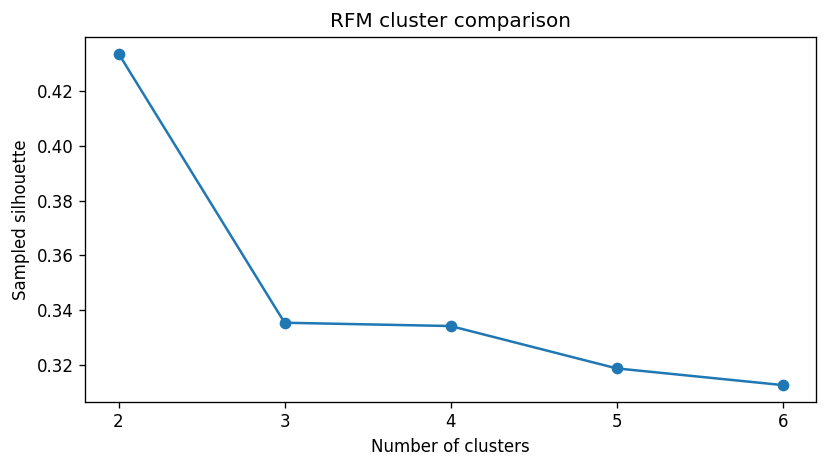

In [4]:
features = ['RecencyDays','Frequency','GrossPurchaseValue']
assert np.isfinite(eligible[features]).all().all()
scaler = StandardScaler()
Z = scaler.fit_transform(np.log1p(eligible[features]))
comparison=[]; fitted={}
for k in range(2,7):
    model = KMeans(n_clusters=k,n_init=20,max_iter=500,random_state=SEED).fit(Z)
    fitted[k]=model
    sizes = np.bincount(model.labels_,minlength=k)
    score = silhouette_score(Z,model.labels_,sample_size=min(3000,len(Z)),random_state=SEED)
    comparison.append({'K':k,'Silhouette':score,'SmallestCluster':int(sizes.min()),'SmallestSharePct':sizes.min()/len(Z)*100,'Inertia':model.inertia_})
cluster_comparison=pd.DataFrame(comparison)
valid_candidates=cluster_comparison.loc[cluster_comparison.SmallestSharePct>=5]
assert len(valid_candidates)>0,'No candidate satisfies minimum size: inspect profiles before changing the rule'
best_k=int(valid_candidates.sort_values('Silhouette',ascending=False).iloc[0].K)
labels=fitted[best_k].labels_
eligible['Cluster']=labels
cluster_comparison.to_csv(OUT/'cluster_comparison.csv',index=False)
print(cluster_comparison.round(4).to_string(index=False)); print('Selected K:',best_k)
fig,ax=plt.subplots(figsize=(7,4)); ax.plot(cluster_comparison.K,cluster_comparison.Silhouette,marker='o'); ax.set(xlabel='Number of clusters',ylabel='Sampled silhouette',title='RFM cluster comparison'); ax.set_xticks(cluster_comparison.K); fig.tight_layout(); fig.savefig(OUT/'cluster_comparison.png'); plt.show(); plt.close(fig)
# Stability across initializations, and sensitivity to capped monetary/frequency tails.
seed_agreements=[]
for seed in [7,21,99]:
    other=KMeans(n_clusters=best_k,n_init=20,max_iter=500,random_state=seed).fit_predict(Z)
    seed_agreements.append({'Check':f'Initialization seed {seed}','AdjustedRandIndex':adjusted_rand_score(labels,other)})
capped=eligible[features].copy()
for col in ['Frequency','GrossPurchaseValue']:
    capped[col]=capped[col].clip(upper=capped[col].quantile(0.99))
Z_cap=StandardScaler().fit_transform(np.log1p(capped))
cap_labels=KMeans(n_clusters=best_k,n_init=20,max_iter=500,random_state=SEED).fit_predict(Z_cap)
seed_agreements.append({'Check':'99th percentile frequency/value caps','AdjustedRandIndex':adjusted_rand_score(labels,cap_labels)})
stability=pd.DataFrame(seed_agreements); stability.to_csv(OUT/'cluster_sensitivity.csv',index=False)
print(stability.round(4).to_string(index=False))

## Profiles in original units and proposed actions
Name groups using their observed median gross purchase value rank; append recent/less-recent and repeat/occasional descriptions relative to the population medians. Labels are relative to this dataset, not validated marketing categories. Actions are hypotheses to test, with no claimed uplift.

         Customers  MedianRecencyDays  MedianOrders  MedianGrossValue  MedianNetSpend  GrossValue  ReturnValue    NetSpend  CustomerSharePct  GrossValueSharePct                                  Segment                                               ProposedAction
Cluster                                                                                                                                                                                                                                                               
0             2672               97.0           1.0            356.92          349.62  1316809.26     31886.36  1284922.90             61.65               15.07  Value tier 1/2: less recent, occasional  Test re-engagement messaging; measure incremental purchases
1             1662               17.0           6.0           2041.33         1995.04  7420418.38    435941.37  6984477.01             38.35               84.93           Value tier 2/2: recent, repeat     Test 

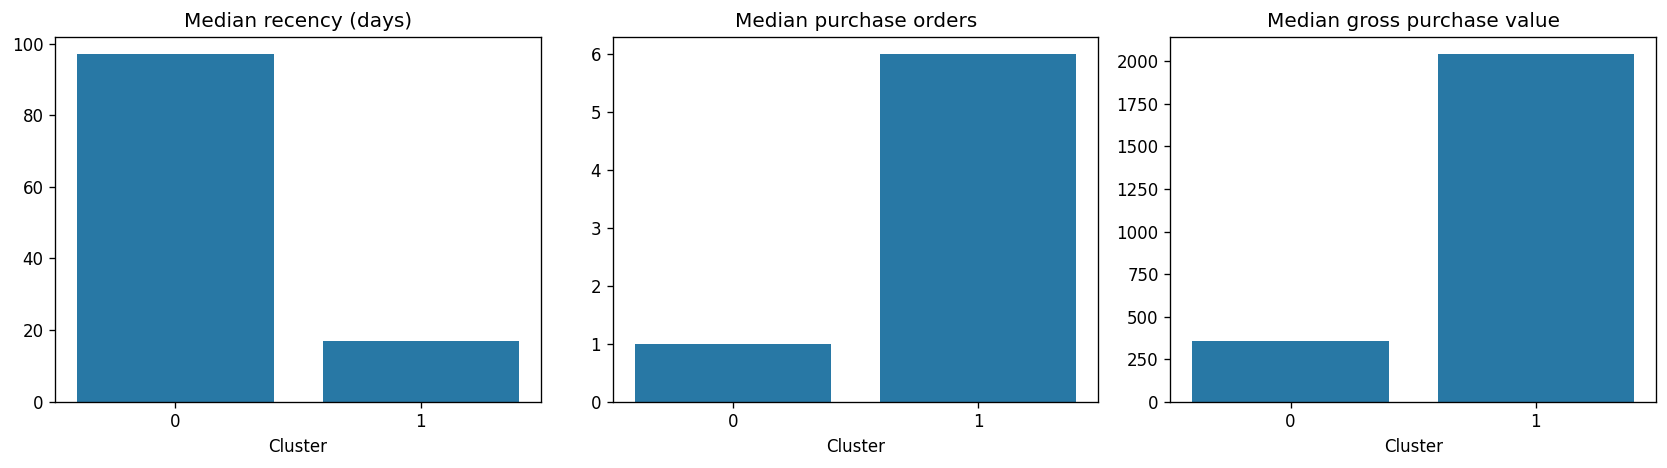

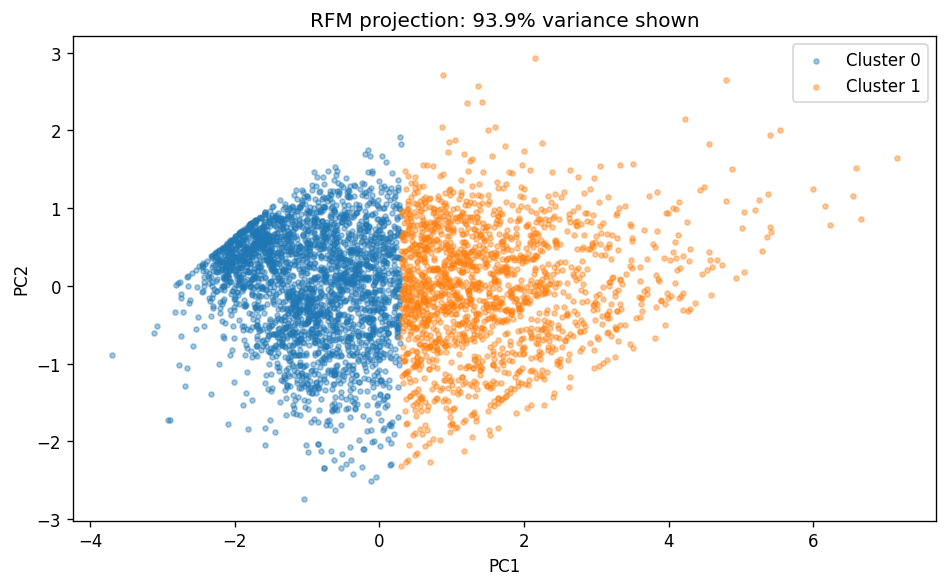

In [5]:
profile=eligible.groupby('Cluster').agg(Customers=('Frequency','size'),MedianRecencyDays=('RecencyDays','median'),MedianOrders=('Frequency','median'),MedianGrossValue=('GrossPurchaseValue','median'),MedianNetSpend=('NetSpend','median'),GrossValue=('GrossPurchaseValue','sum'),ReturnValue=('ReturnValue','sum'),NetSpend=('NetSpend','sum'))
profile['CustomerSharePct']=profile.Customers/len(eligible)*100
profile['GrossValueSharePct']=profile.GrossValue/eligible.GrossPurchaseValue.sum()*100
rank=profile.MedianGrossValue.rank(method='first').astype(int)
names={}; actions={}
for cluster,row in profile.iterrows():
    value=f'Value tier {rank.loc[cluster]}/{best_k}'
    recent='recent' if row.MedianRecencyDays<=eligible.RecencyDays.median() else 'less recent'
    repeat='repeat' if row.MedianOrders>eligible.Frequency.median() else 'occasional'
    names[cluster]=f'{value}: {recent}, {repeat}'
    actions[cluster]=('Test loyalty/service offers and monitor repeat purchases' if rank.loc[cluster]==best_k and recent=='recent' else 'Test re-engagement messaging; measure incremental purchases' if recent=='less recent' else 'Test second-purchase offers; measure incremental repeat rate')
profile['Segment']=pd.Series(names); profile['ProposedAction']=pd.Series(actions)
eligible['Segment']=eligible.Cluster.map(names)
assert profile.Customers.sum()==len(eligible)
np.testing.assert_allclose(profile.GrossValue.sum(),eligible.GrossPurchaseValue.sum())
np.testing.assert_allclose(profile.NetSpend.sum(),eligible.NetSpend.sum())
profile.to_csv(OUT/'segment_profiles.csv')
eligible.to_csv(OUT/'customer_segments.csv')
print(profile.round(2).to_string())
fig,axes=plt.subplots(1,3,figsize=(14,4))
for ax,col,title in zip(axes,['MedianRecencyDays','MedianOrders','MedianGrossValue'],['Median recency (days)','Median purchase orders','Median gross purchase value']):
    ax.bar(profile.index.astype(str),profile[col],color='#2878a5'); ax.set(xlabel='Cluster',title=title)
fig.tight_layout(); fig.savefig(OUT/'segment_profiles.png'); plt.show(); plt.close(fig)
pca=PCA(n_components=2,random_state=SEED); projection=pca.fit_transform(Z)
fig,ax=plt.subplots(figsize=(8,5))
for cluster in sorted(profile.index):
    mask=labels==cluster; ax.scatter(projection[mask,0],projection[mask,1],s=9,alpha=0.4,label=f'Cluster {cluster}')
ax.set(xlabel='PC1',ylabel='PC2',title=f'RFM projection: {pca.explained_variance_ratio_.sum():.1%} variance shown'); ax.legend(); fig.tight_layout(); fig.savefig(OUT/'cluster_projection.png'); plt.show(); plt.close(fig)

## Preserve the actual recommendation method
This is a simple segment-popularity heuristic, not ALS or a trained collaborative-filtering system. Rank products by distinct purchase invoices within each segment, excluding previously purchased items. Return up to three suggestions per customer; missing suggestions stay blank. No recommendation accuracy, future sales or retention benefit has been validated.

In [6]:
tagged=purchases.merge(eligible[['Cluster']].reset_index(),on='CustomerID',how='inner',validate='many_to_one')
assert len(tagged)==len(purchases)
popular=tagged.groupby(['Cluster','StockCode']).agg(PurchaseInvoices=('InvoiceNo','nunique'),Units=('Quantity','sum')).reset_index().sort_values(['Cluster','PurchaseInvoices','StockCode'],ascending=[True,False,True])
popular.groupby('Cluster').head(10).to_csv(OUT/'top_products_by_segment.csv',index=False)
bought=tagged.groupby('CustomerID').StockCode.agg(set).to_dict()
catalog={cluster:group.StockCode.head(50).tolist() for cluster,group in popular.groupby('Cluster')}
rows=[]
for customer,row in eligible.iterrows():
    suggestions=[item for item in catalog[row.Cluster] if item not in bought[customer]][:3]
    entry={'CustomerID':customer,'Cluster':int(row.Cluster)}
    entry.update({f'Recommendation{i+1}':suggestions[i] if i<len(suggestions) else None for i in range(3)})
    assert not set(suggestions)&bought[customer]
    rows.append(entry)
recommendations=pd.DataFrame(rows); assert recommendations.CustomerID.is_unique
recommendations.to_csv(OUT/'segment_popularity_recommendations.csv',index=False)
print(recommendations.head().to_string(index=False))

CustomerID  Cluster Recommendation1 Recommendation2 Recommendation3
     12346        1          85123A          85099B           22423
     12347        1          85123A          85099B           20725
     12348        1          85123A          85099B           22423
     12349        0          85123A           84879           47566
     12350        0          85123A           22423           84879


In [7]:
lines=['# Verified customer segmentation findings','',f'Input rows: {len(raw):,}. RFM eligible customers: {len(eligible):,}. Reference date: {reference_date.date()}.',f'Selected k={best_k}; sampled silhouette={float(cluster_comparison.loc[cluster_comparison.K.eq(best_k),"Silhouette"].iloc[0]):.3f}. Groups can overlap; no claim of sharply separated customer types.','']
for cluster,row in profile.iterrows():
    lines.append(f'- Cluster {cluster} ({row.Segment}): {int(row.Customers):,} customers ({row.CustomerSharePct:.1f}%); median recency {row.MedianRecencyDays:.0f} days, orders {row.MedianOrders:.0f}, gross value {row.MedianGrossValue:.2f}, net spend {row.MedianNetSpend:.2f}. Proposed action: {row.ProposedAction}.')
lines.extend(['','## Decisions and limitations','Missing customer identities excluded from customer analysis; exact duplicate removal is an assumption. Merchandise scope excludes listed non-product codes. Credits are not matched to original purchases; net spend is within-window transaction arithmetic. Return-only customers are exported but not clustered. Outliers retained; sensitivity check exported. Recommendations are segment popularity, not ALS. Original upload provenance and currency must be verified against source documentation. Historical clusters do not prove churn, marketing effectiveness or causal effects. Test proposed actions with a suitable controlled evaluation.','', 'All customer, financial, join and recommendation checks passed during execution.'])
(OUT/'findings.md').write_text('\n'.join(lines),encoding='utf-8')
(OUT/'run_summary.json').write_text(json.dumps({'RawRows':len(raw),'EligibleCustomers':len(eligible),'Clusters':best_k,'ReferenceDate':str(reference_date.date()),'Features':features},indent=2))
print('\n'.join(lines))

# Verified customer segmentation findings

Input rows: 541,909. RFM eligible customers: 4,334. Reference date: 2011-12-10.
Selected k=2; sampled silhouette=0.434. Groups can overlap; no claim of sharply separated customer types.

- Cluster 0 (Value tier 1/2: less recent, occasional): 2,672 customers (61.7%); median recency 97 days, orders 1, gross value 356.91, net spend 349.62. Proposed action: Test re-engagement messaging; measure incremental purchases.
- Cluster 1 (Value tier 2/2: recent, repeat): 1,662 customers (38.3%); median recency 17 days, orders 6, gross value 2041.33, net spend 1995.04. Proposed action: Test loyalty/service offers and monitor repeat purchases.

## Decisions and limitations
Missing customer identities excluded from customer analysis; exact duplicate removal is an assumption. Merchandise scope excludes listed non-product codes. Credits are not matched to original purchases; net spend is within-window transaction arithmetic. Return-only customers are exported b